# **🏏 IPL Cricket Data Analysis**

# Import Libraries

---



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

* pandas → handle data tables
* numpy → calculations
* matplotlib / seaborn → charts

# Upload Dataset

---



In [5]:
df = pd.read_csv("deliveries.csv")
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [6]:
# understand data
df.shape

(150460, 21)

In [7]:
df.columns


Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [9]:
# Show numeric summary
df.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000
mean,318.281317,1.482188,10.142649,3.616483,0.000538,0.037498,0.004885,0.022232,0.004340,0.000066,1.222445,0.069022,1.291466
std,182.955531,0.501768,5.674338,1.807698,0.023196,0.257398,0.114234,0.200104,0.072652,0.018229,1.594509,0.349667,1.583240
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,161.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,319.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,476.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,636.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,6.000000,7.000000,7.000000


# Data Cleaning

---



In [10]:
# Check missing values
df.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


In [11]:
# Fill the missing value
df = df.fillna(0)

# BATTING ANALYSIS

---



In [13]:
# Top 10 scorer
top_batsman = df.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)
print(top_batsman)

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64


* Group by player name
* Sum total runs
* Sort highest first

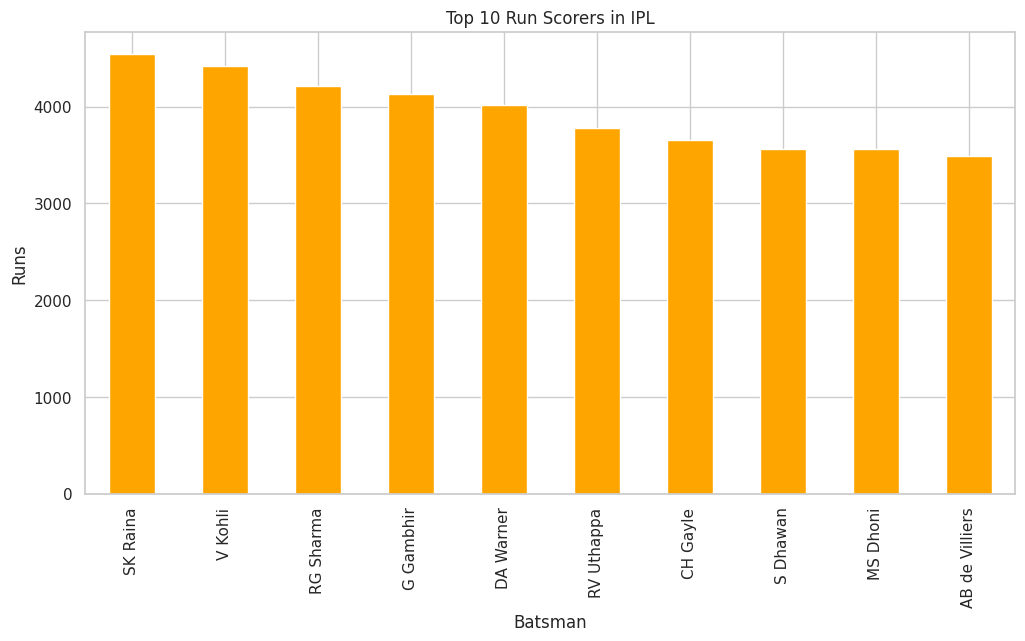

In [14]:
# Top Batsman
top_batsman.plot(kind="bar", color="orange")
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()

# Most Sixes

---



In [15]:
most_sixes = df[df["batsman_runs"] == 6].groupby("batsman").size().sort_values(ascending=False).head(10)
print(most_sixes)

batsman
CH Gayle          266
SK Raina          174
RG Sharma         173
DA Warner         160
V Kohli           160
AB de Villiers    158
MS Dhoni          156
YK Pathan         149
KA Pollard        148
Yuvraj Singh      141
dtype: int64


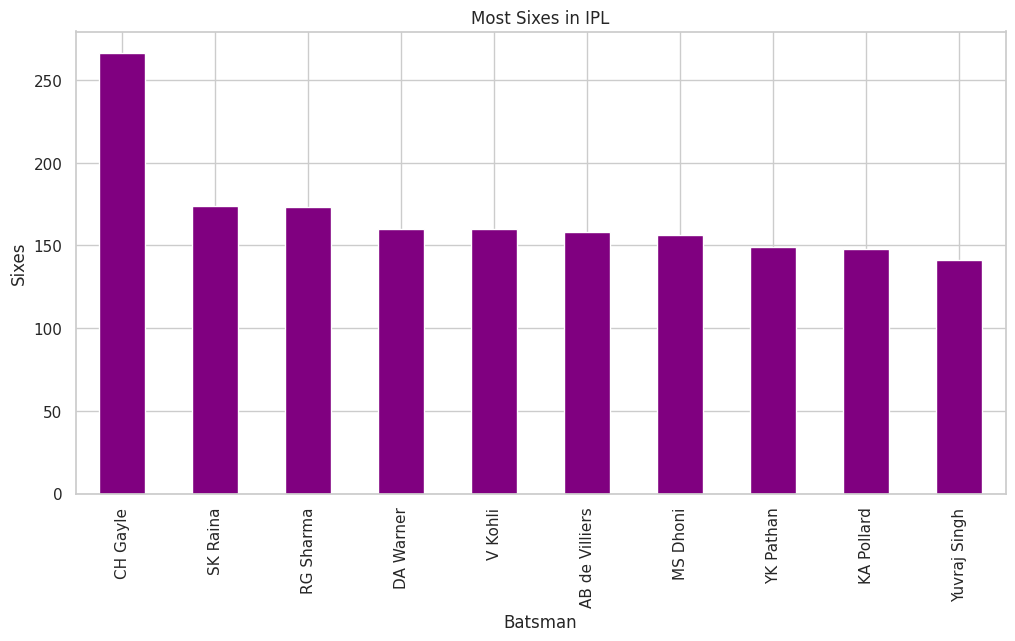

In [16]:
# Most Sixes
most_sixes.plot(kind="bar", color="purple")
plt.title("Most Sixes in IPL")
plt.xlabel("Batsman")
plt.ylabel("Sixes")
plt.show()

# Most Fours

---



In [17]:
most_fours = df[df["batsman_runs"] == 4].groupby("batsman").size().sort_values(ascending=False).head(10)
print(most_fours)

batsman
G Gambhir     484
SK Raina      402
DA Warner     401
S Dhawan      401
V Kohli       384
RV Uthappa    377
RG Sharma     354
V Sehwag      334
AM Rahane     320
CH Gayle      297
dtype: int64


# TEAM ANALYSIS

---



# Team Total Runs

In [18]:
team_runs = df.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False)
print(team_runs)

batting_team
Mumbai Indians                 24521
Royal Challengers Bangalore    23436
Kings XI Punjab                23068
Kolkata Knight Riders          21965
Delhi Daredevils               21953
Chennai Super Kings            20899
Rajasthan Royals               17703
Sunrisers Hyderabad            11652
Deccan Chargers                11463
Pune Warriors                   6358
Gujarat Lions                   4862
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64


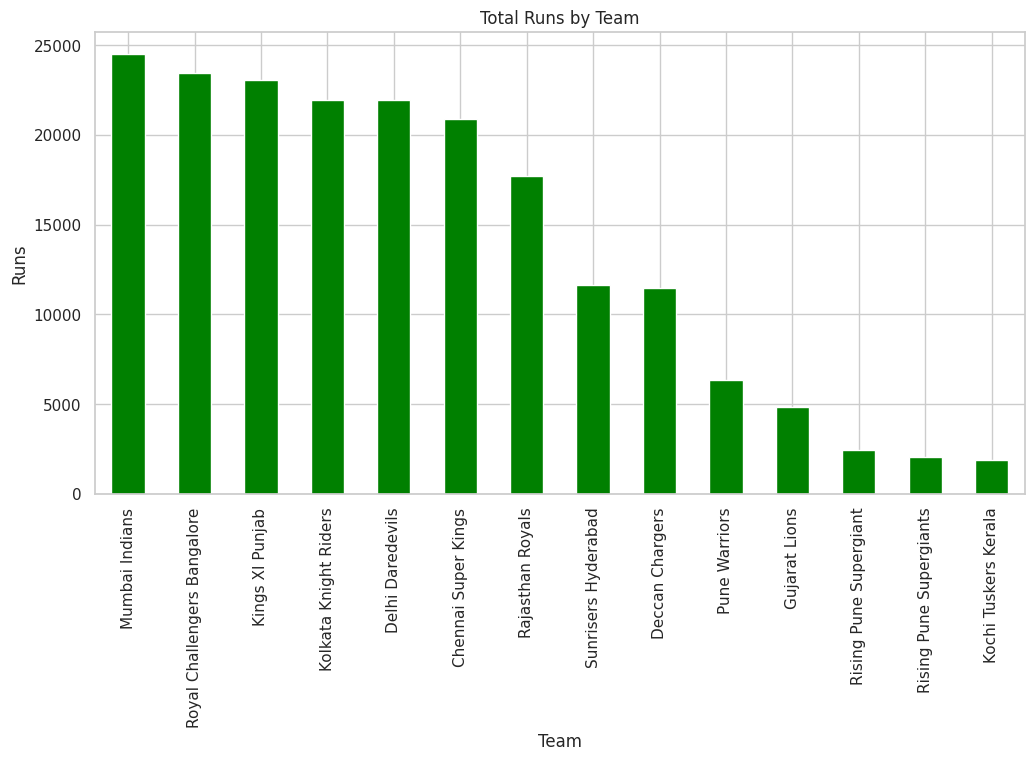

In [19]:
#Team Runs Chart
team_runs.plot(kind="bar", color="green")
plt.title("Total Runs by Team")
plt.xlabel("Team")
plt.ylabel("Runs")
plt.show()

### Matches Played by Team

In [20]:
matches_played = df["batting_team"].value_counts()
print(matches_played)

batting_team
Mumbai Indians                 18943
Royal Challengers Bangalore    17678
Kings XI Punjab                17594
Kolkata Knight Riders          17229
Delhi Daredevils               17185
Chennai Super Kings            15754
Rajasthan Royals               13914
Sunrisers Hyderabad             9058
Deccan Chargers                 9034
Pune Warriors                   5443
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64


# BOWLING ANALYSIS

---



### Most Wickets by Bowler

In [21]:
wickets = df[df["player_dismissed"] != "Not Out"].groupby("bowler").size().sort_values(ascending=False).head(10)
print(wickets)

bowler
Harbhajan Singh    2989
A Mishra           2703
SL Malinga         2694
P Kumar            2637
PP Chawla          2594
R Ashwin           2359
Z Khan             2276
R Vinay Kumar      2161
DW Steyn           2159
IK Pathan          2113
dtype: int64


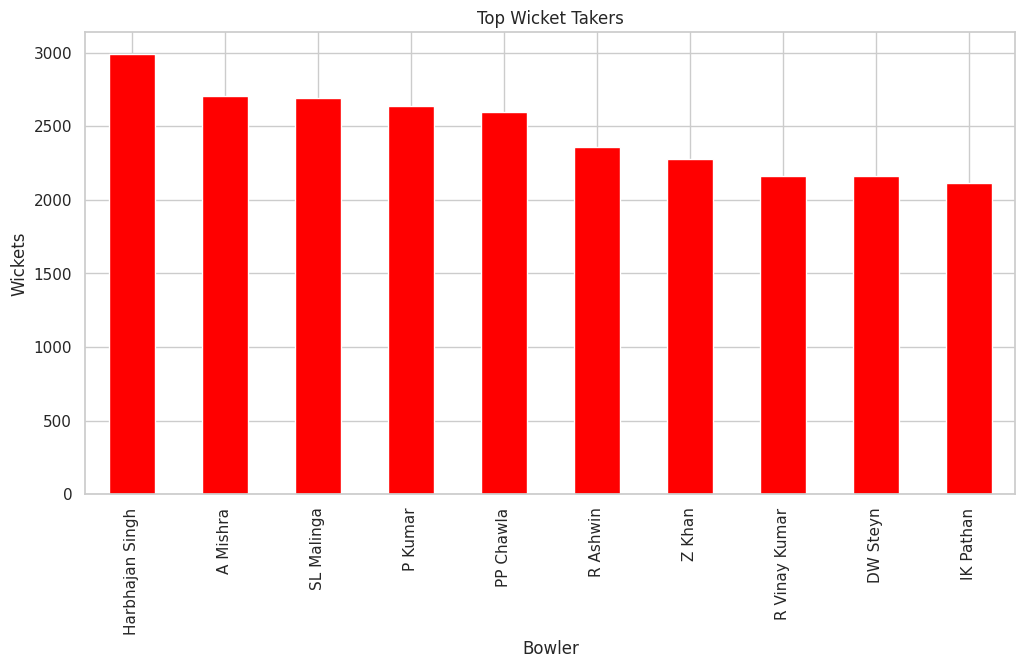

In [22]:
#Wickets chart
wickets.plot(kind="bar", color="red")
plt.title("Top Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()

# MATCH INSIGHTS

---



In [24]:
# Highest Team Scores in a Match
highest_score = df.groupby(["match_id", "batting_team"])["total_runs"].sum().reset_index()
top_scores = highest_score.sort_values("total_runs", ascending=False).head(10)
print(top_scores)

      match_id                 batting_team  total_runs
820        411  Royal Challengers Bangalore         263
1237       620  Royal Challengers Bangalore         248
410        206          Chennai Super Kings         246
120         61          Chennai Super Kings         240
1121       562  Royal Challengers Bangalore         235
590        296              Kings XI Punjab         232
970        486              Kings XI Punjab         231
516        259             Delhi Daredevils         231
98          50              Kings XI Punjab         230
1156       580  Royal Challengers Bangalore         227


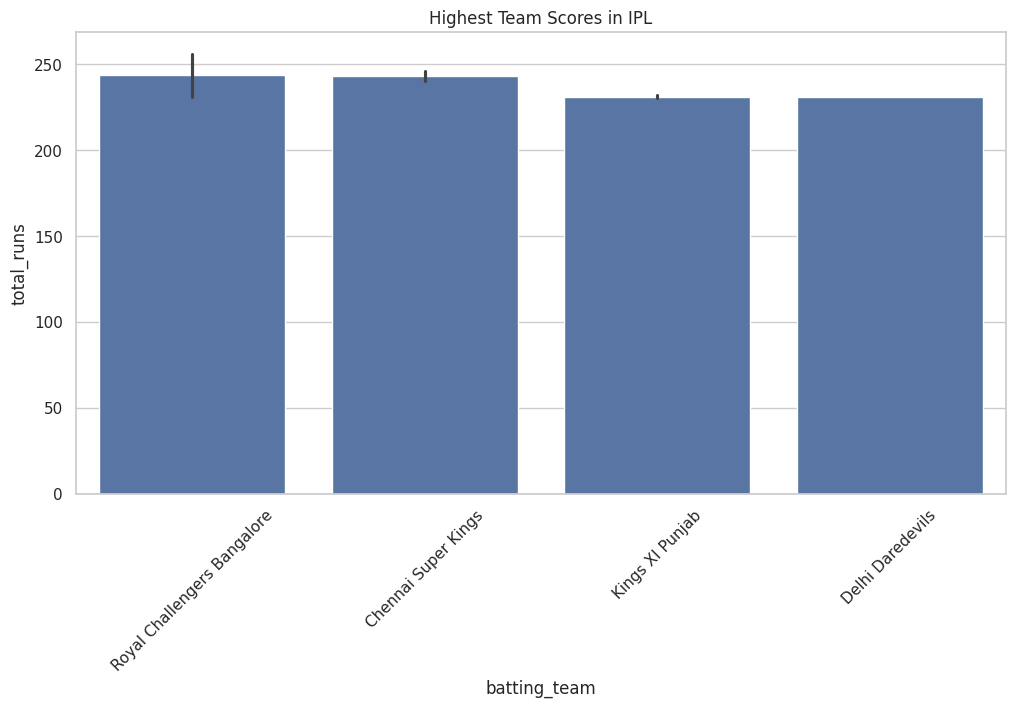

In [25]:
# Highest Score Chart
sns.barplot(x="batting_team", y="total_runs", data=top_scores)
plt.title("Highest Team Scores in IPL")
plt.xticks(rotation=45)
plt.show()

In [26]:
# Runs by Over
over_runs = df.groupby("over")["total_runs"].sum()
print(over_runs)

over
1      7733
2      8993
3      9852
4     10207
5     10227
6     10397
7      8413
8      8966
9      9247
10     9047
11     9456
12     9694
13     9713
14     9900
15    10240
16    10397
17    10817
18    10899
19    10469
20     9647
Name: total_runs, dtype: int64


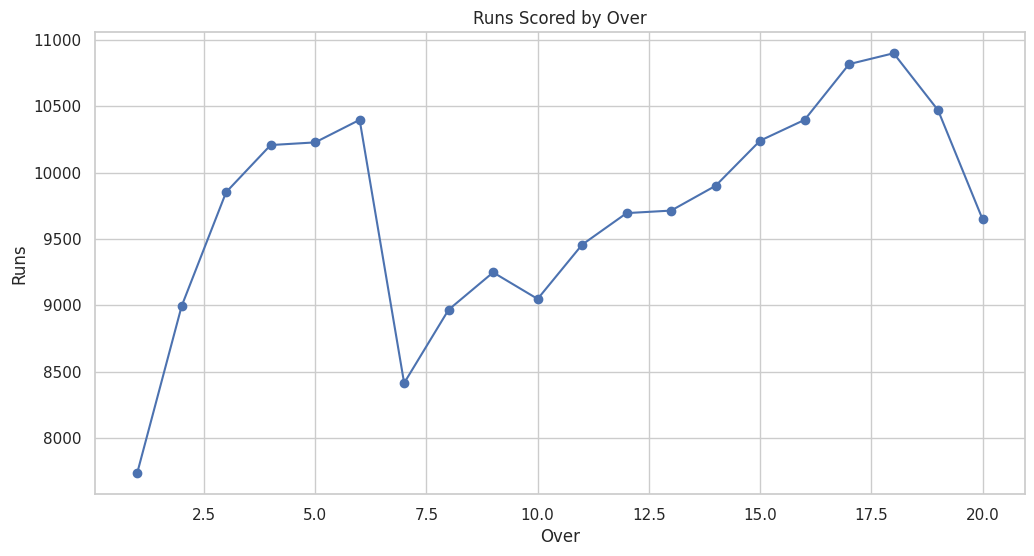

In [27]:
# Over-wise Runs Chart
over_runs.plot(kind="line", marker="o")
plt.title("Runs Scored by Over")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

In [37]:
# Dismissals Type
dismissals = df[
    (df["dismissal_kind"] != 0) &
    (df["dismissal_kind"] != "0") &
    (df["dismissal_kind"] != "Not Out") &
    (df["dismissal_kind"].notna())
]["dismissal_kind"].value_counts()

print(dismissals)

dismissal_kind
caught                   4373
bowled                   1382
run out                   755
lbw                       455
stumped                   243
caught and bowled         211
retired hurt                9
hit wicket                  9
obstructing the field       1
Name: count, dtype: int64


/tmp/ipykernel_3757/2673597244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


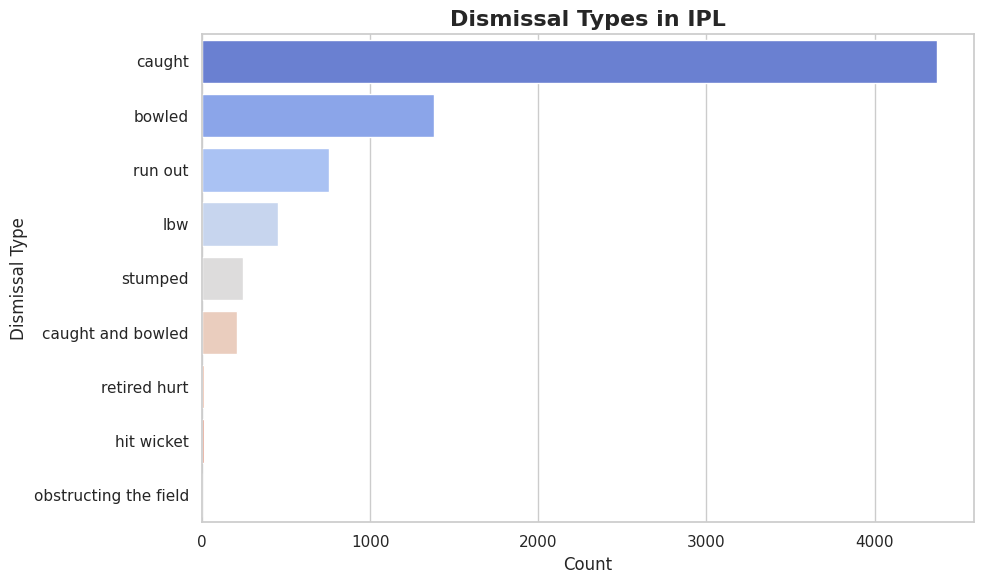

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=dismissals.values,
    y=dismissals.index,
    palette="coolwarm"
)

plt.title("Dismissal Types in IPL", fontsize=16, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Dismissal Type")
plt.tight_layout()
plt.show()

In [38]:
# Save Cleaned File
df.to_csv("cleaned_ipl.csv", index=False)